# Shelter Indices at 1m Resolution

Demonstrates running the full shelterbelts indices pipeline on a 1m canopy height model. Units are still in pixels (but now 1 pixel = 1m, compared to normally when 1 pixel = 10m).

In this example, we have 4 combinations of parameters: 

| # | Name | Wind Method | Notes |
|---|------|--------|-------|
| 1 | Default percent | percent | Tree cover within 100m is > 5% |
| 4 | Default wind | WINDWARD | 100% shelter in the leeward direction & 50% in the windward direction |
| 5 | More shelter | ANY | Shelter provided in any wind direction |
| 6 | Less shelter | MOST_COMMON | Shelter only provided in the leeward direction |

In [1]:
from shelterbelts.indices.all_indices import indices_tif
from shelterbelts.indices.shelter_categories import shelter_categories_cmap, shelter_categories_labels
from shelterbelts.utils.visualisation import visualise_categories
from shelterbelts.utils.filepaths import _repo_root

percent_tif = str(_repo_root / 'data' / 'demo_crowns_chm_res1_500m_Sep.tif')
outdir = str(_repo_root / 'outdir')
debug = False

## 1. Default percent method

In [19]:
%%time
ds1, df1 = indices_tif(
    percent_tif,
    outdir=outdir,
    stub='crowns_default_percent',
    cover_threshold=1,
    crop_pixels=0,
    distance_threshold=100,
    buffer_width=40,
    max_shelterbelt_width=60,
    min_shelterbelt_length=100,
    min_patch_size=200,
    edge_size=30,
    min_core_size=10000,
    debug=debug,
)

Saved: /home/christopher-bradley/repos/shelterbelts/outdir/crowns_default_percent_linear_categories.tif
CPU times: user 3.56 s, sys: 512 ms, total: 4.07 s
Wall time: 4.07 s


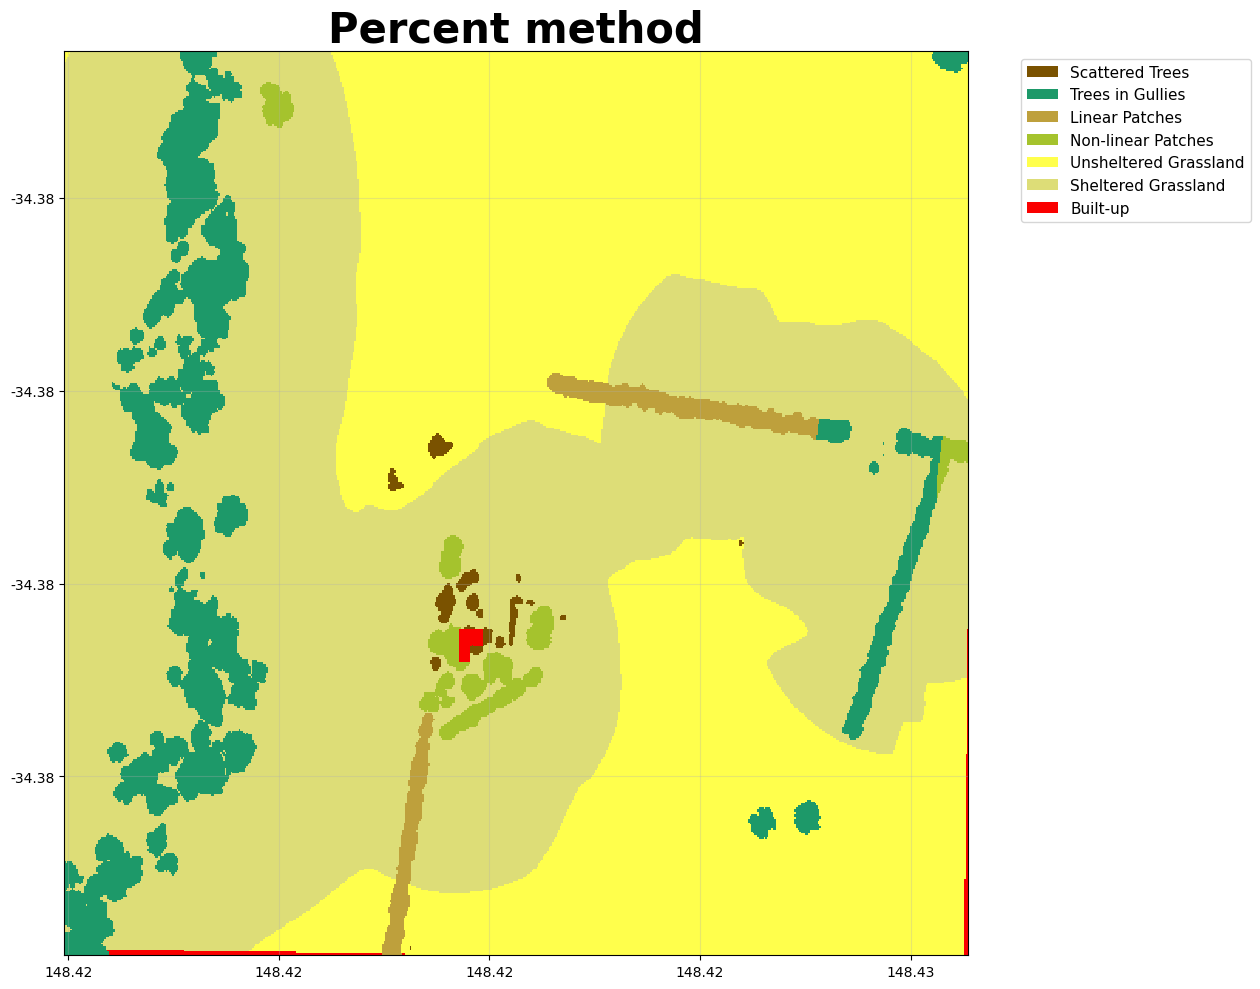

In [20]:
visualise_categories(
    ds1['shelter_categories'],
    colormap=shelter_categories_cmap,
    labels=shelter_categories_labels,
    title='Percent method',
)

In [4]:
df1.head()

,label,ellipse_length,ellipse_width,ellipse len/width,perimeter,area,orientation_degrees,skeleton_width,skeleton_length,skeleton len/width,category_id,category_name
0,1,261.059038,63.228416,4.128825,1205.182900,7763.0,-6.304827,18.955211,269,14.191348,15.0,Trees in Gullies
1,2,24.588578,13.184452,1.864968,64.970563,241.0,88.585348,13.428675,17,1.265948,15.0,Trees in Gullies
2,3,23.944783,14.175010,1.689225,63.556349,258.0,88.316510,10.619220,17,1.600871,15.0,Trees in Gullies
3,4,219.938345,26.856204,8.189480,466.374675,2143.0,-16.079490,10.406656,168,16.143514,15.0,Trees in Gullies
4,5,24.252221,19.949289,1.215693,76.526912,368.0,-35.534361,13.592744,12,0.882824,15.0,Trees in Gullies


## 4. Default wind method


In [13]:
%%time
ds4, df4 = indices_tif(
    percent_tif,
    outdir=outdir,
    stub='crowns_default_wind',
    cover_threshold=1,
    crop_pixels=0,
    wind_method='WINDWARD',
    distance_threshold=100,
    buffer_width=40,
    max_shelterbelt_width=60,
    min_shelterbelt_length=100,
    min_patch_size=200,
    edge_size=30,
    min_core_size=10000,
    debug=debug,
)

Saved: /home/christopher-bradley/repos/shelterbelts/outdir/crowns_default_wind_linear_categories.tif
CPU times: user 4.92 s, sys: 568 ms, total: 5.49 s
Wall time: 8.68 s


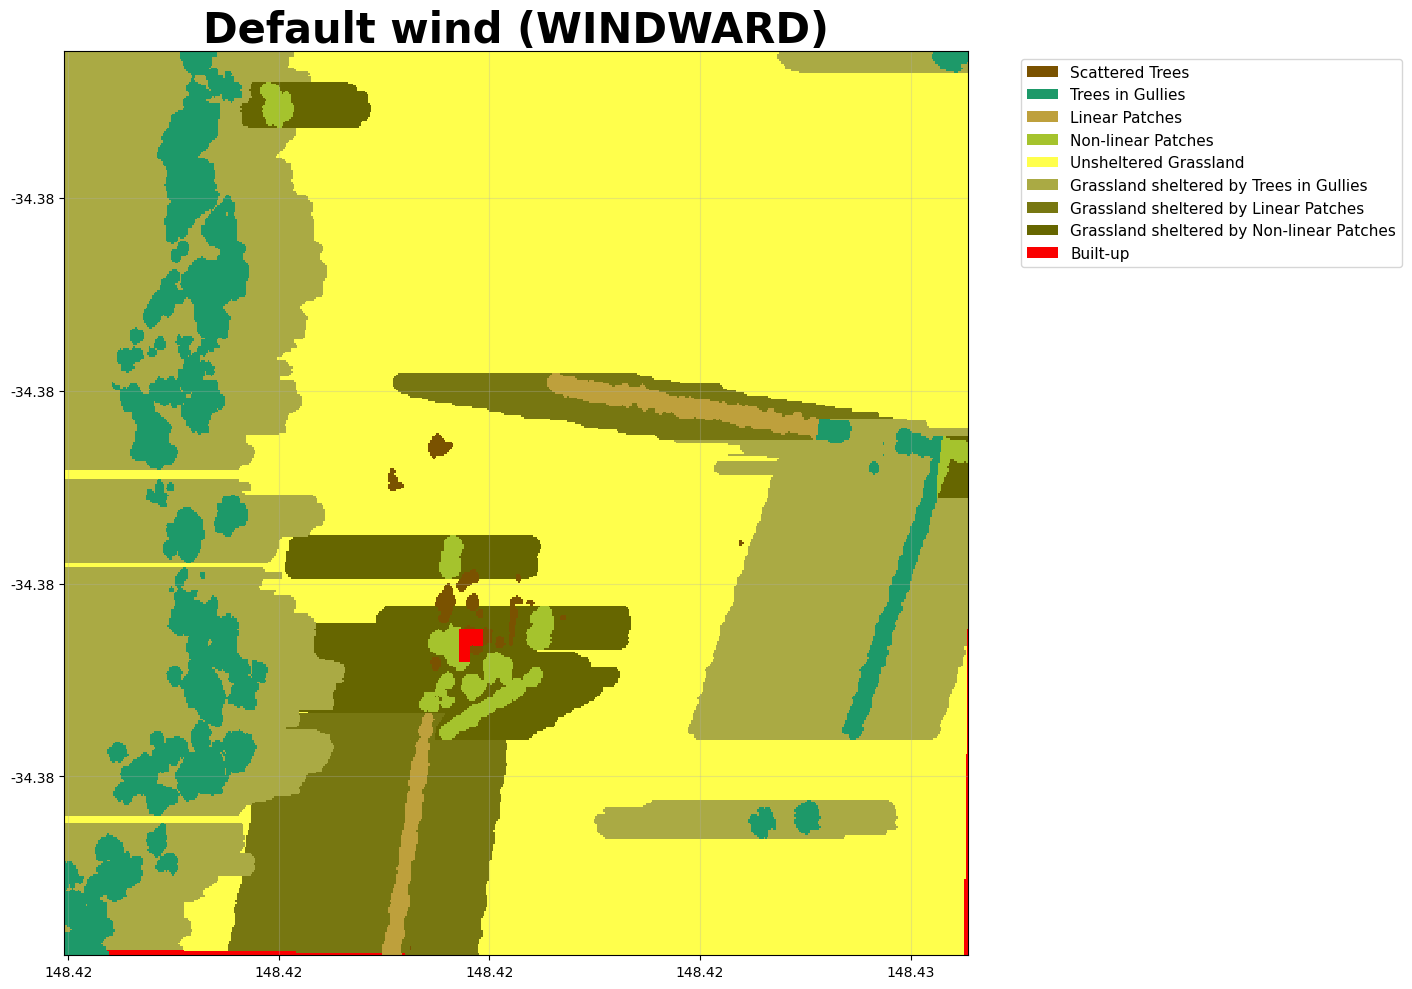

In [14]:
visualise_categories(
    ds4['shelter_categories'],
    colormap=shelter_categories_cmap,
    labels=shelter_categories_labels,
    title='Default wind (WINDWARD)',
)

## 5. More shelter — wind method


In [15]:
%%time
ds5, df5 = indices_tif(
    percent_tif,
    outdir=outdir,
    stub='crowns_more_wind',
    cover_threshold=1,
    crop_pixels=0,
    wind_method='ANY',
    distance_threshold=100,
    buffer_width=50,
    max_shelterbelt_width=70,
    min_shelterbelt_length=100,
    min_patch_size=150,
    edge_size=50,
    min_core_size=100000,
    wind_threshold=150,
    debug=debug,
)

Saved: /home/christopher-bradley/repos/shelterbelts/outdir/crowns_more_wind_linear_categories.tif
CPU times: user 14 s, sys: 3.11 s, total: 17.1 s
Wall time: 20 s


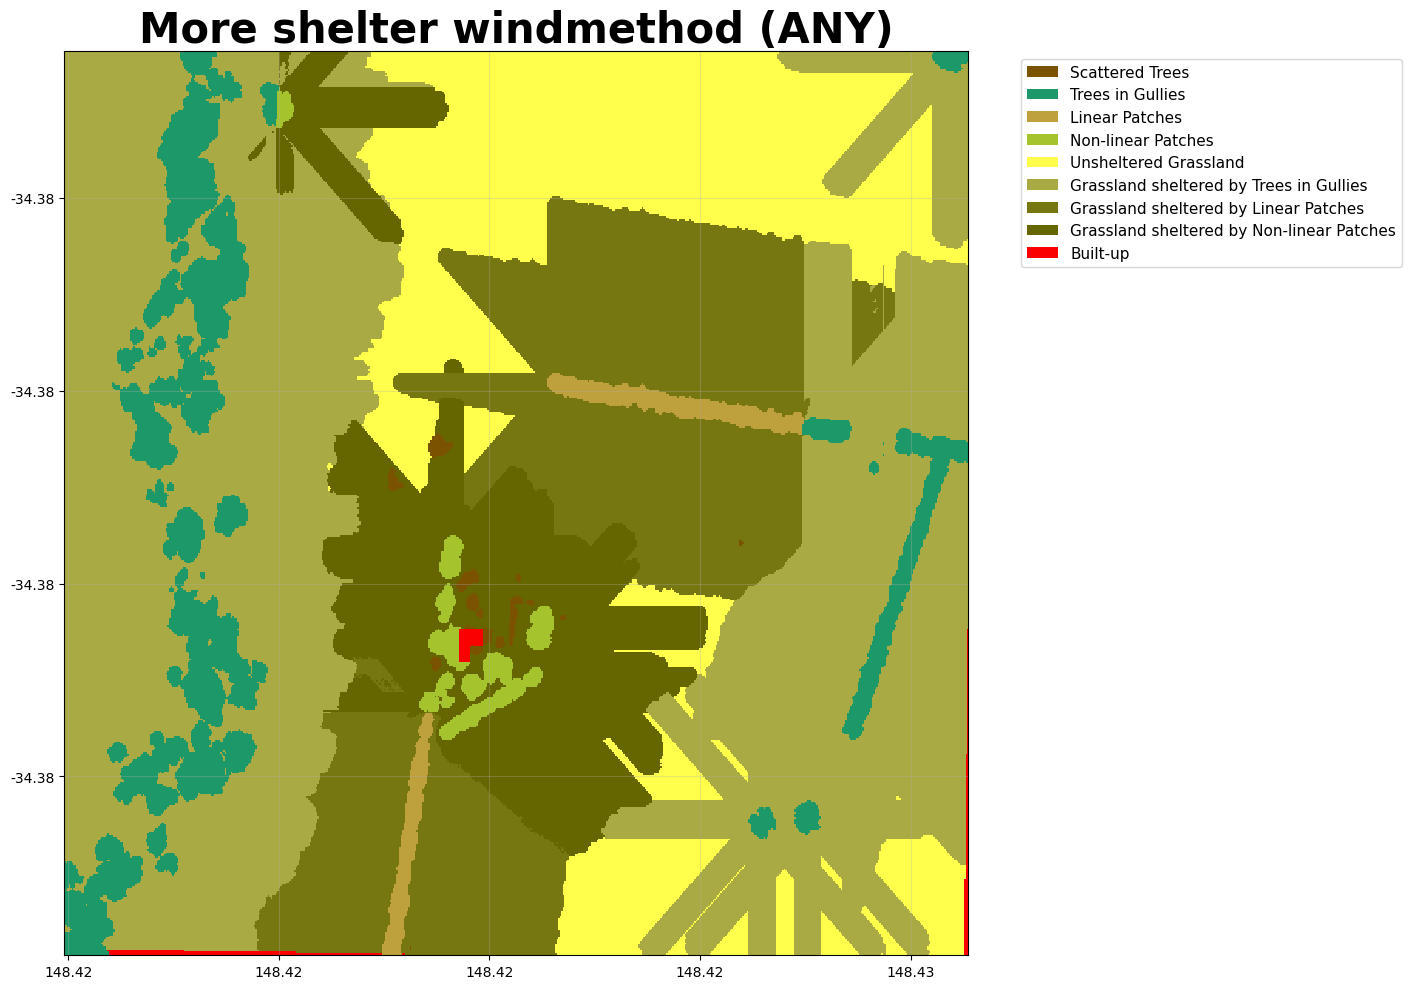

In [16]:
visualise_categories(
    ds5['shelter_categories'],
    colormap=shelter_categories_cmap,
    labels=shelter_categories_labels,
    title='More shelter windmethod (ANY)',
)

## 6. Less shelter — wind method


In [17]:
%%time
ds6, df6 = indices_tif(
    percent_tif,
    outdir=outdir,
    stub='crowns_less_wind',
    cover_threshold=1,
    crop_pixels=0,
    wind_method='MOST_COMMON',
    distance_threshold=100,
    buffer_width=30,
    max_shelterbelt_width=50,
    min_shelterbelt_length=100,
    min_patch_size=250,
    edge_size=20,
    min_core_size=1000,
    wind_threshold=25,
    debug=debug,
)

Saved: /home/christopher-bradley/repos/shelterbelts/outdir/crowns_less_wind_linear_categories.tif
CPU times: user 2.94 s, sys: 188 ms, total: 3.13 s
Wall time: 6.2 s


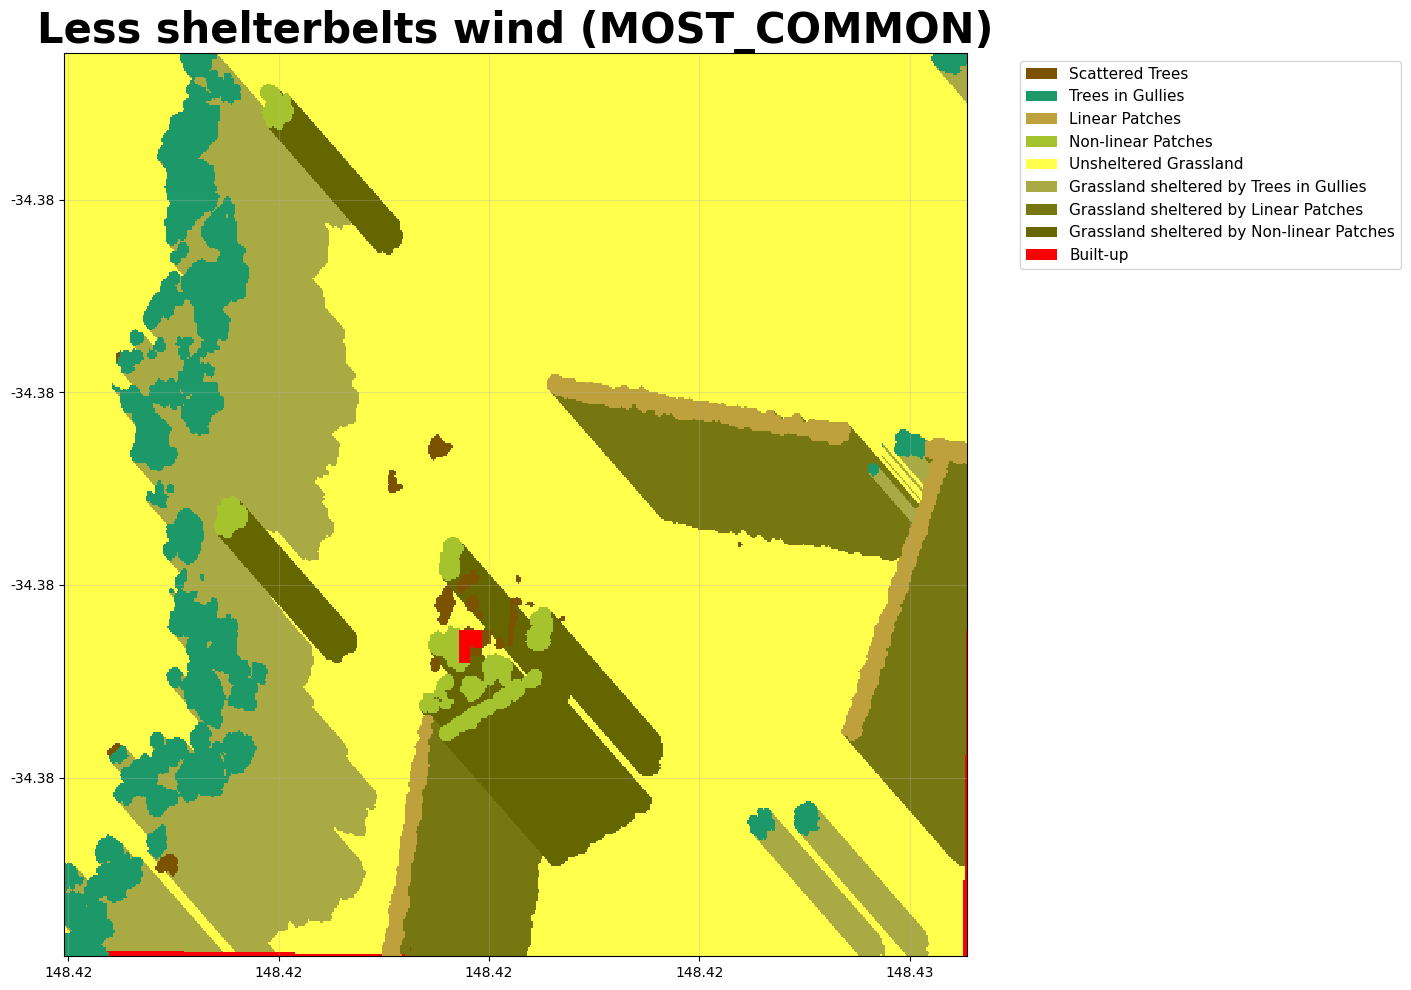

In [18]:
visualise_categories(
    ds6['shelter_categories'],
    colormap=shelter_categories_cmap,
    labels=shelter_categories_labels,
    title='Less shelterbelts wind (MOST_COMMON)',
)

## Summary — all four side by side

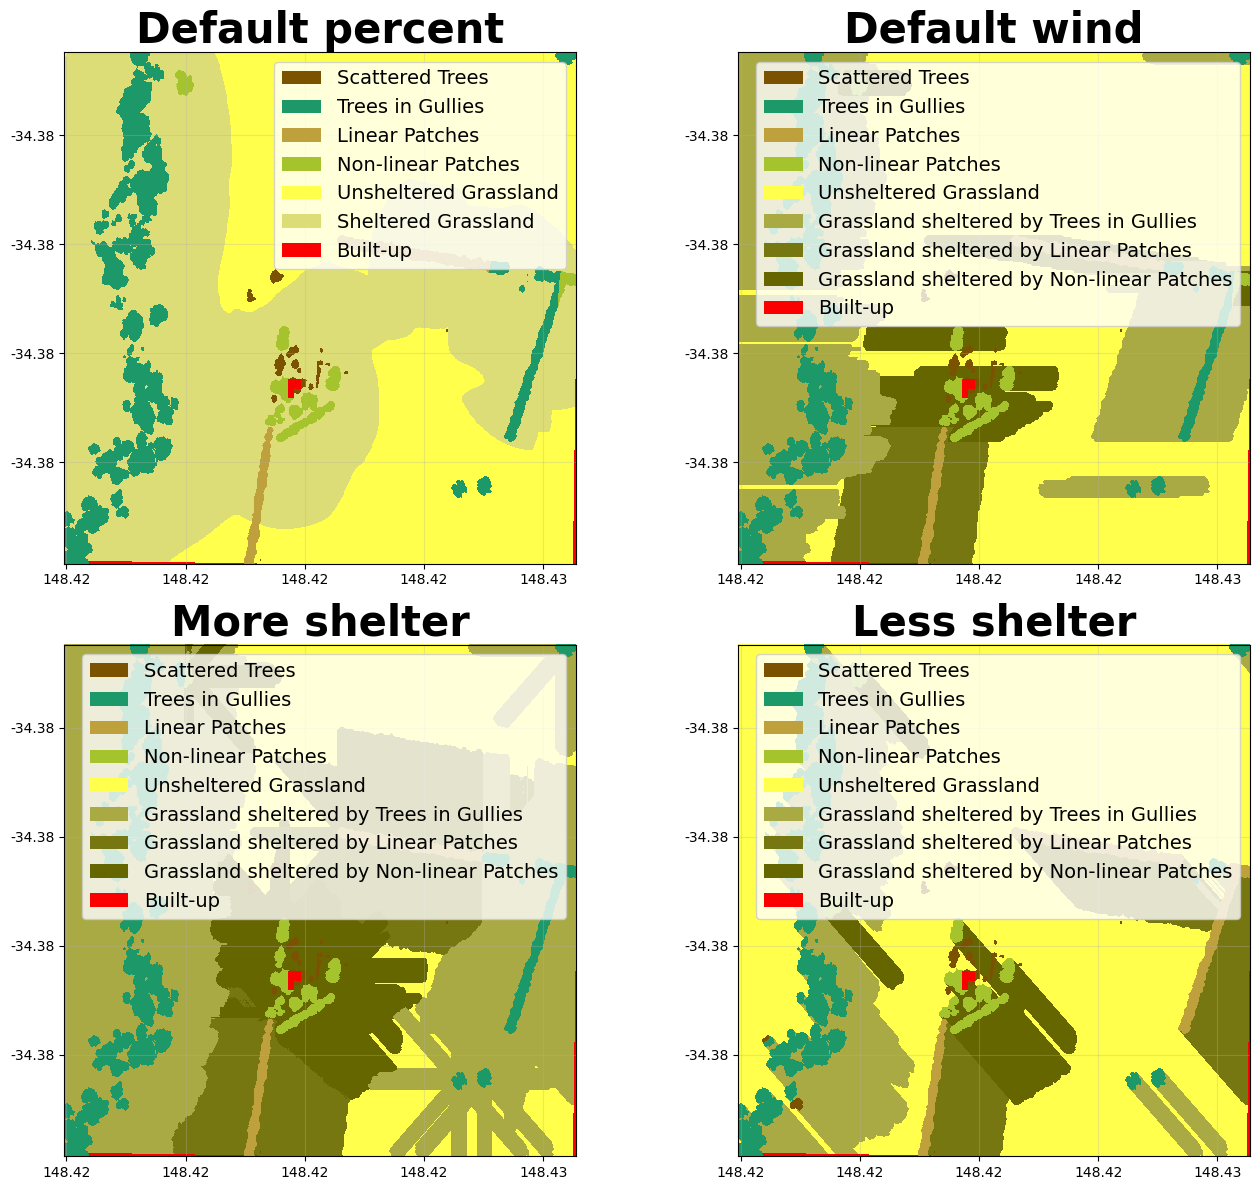

In [21]:
import matplotlib.pyplot as plt
from shelterbelts.utils.visualisation import _plot_categories_on_axis

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
pairs = [
    (ds1, 'Default percent'),
    (ds4, 'Default wind'),
    (ds5, 'More shelter'),
    (ds6, 'Less shelter'),
]
for ax, (ds, title) in zip(axes.flat, pairs):
    _plot_categories_on_axis(ax, ds['shelter_categories'], shelter_categories_cmap, shelter_categories_labels, title, legend_inside=True)
plt.tight_layout()
plt.show()

### Cleanup

In [12]:
# !rm outdir/crowns_*.tif
# !rm outdir/crowns_*.csv
# !rm outdir/crowns_*.gpkg